In [52]:
import numpy as np
import pandas as pandas
import torch
import torch.nn as nn
from torch.optim import Adam, RMSprop
from sklearn.model_selection import train_test_split

In [133]:
#I want my xs to be a sample of numeric numbers from -10 to 10, my y to be x^3
X = np.arange(-5.0, 5.0, 0.001, dtype = np.float32)
y = np.tanh(X) + np.sin(2*X) + np.cos(3*X) + np.exp(X) + np.log(np.abs(X+1)) + np.sqrt(np.abs(X+0.1)) + np.square(X) + np.cbrt(X) + np.square(X)
trainX, testX, train_y, test_y = train_test_split(X, y, test_size = 0.1)
#expand first axis dimension for each

trainX.shape, testX.shape, train_y.shape, test_y.shape

((9000,), (1000,), (9000,), (1000,))

In [134]:
from torch.utils.data import Dataset, DataLoader
class myData(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
train_data = DataLoader(dataset = myData(trainX, train_y), batch_size=16)
test_data = DataLoader(dataset = myData(testX, test_y), batch_size=16)

In [135]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(1, 100)
        self.fc2 = nn.Linear(100, 200)
        self.fc3 = nn.Linear(200, 400)
        self.fc4 = nn.Linear(400, 200)
        self.out = nn.Linear(200, 1)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        #avoid mat1 mat2 wrong dtype error
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.out(x)
        return x
net = Net()

In [136]:
criterion = nn.MSELoss()
optim = torch.optim.SGD(net.parameters(), lr=0.001)

In [137]:
for epoch in range(100):
    running_loss = 0.0
    net.train()
    for i, (tx, ty) in enumerate(train_data):
        optim.zero_grad()
        tx, ty = tx.unsqueeze(1), ty.unsqueeze(1)
        out = net(tx)
        #print(out, ty)
        loss = criterion(out, ty)
        loss.backward()
        optim.step()

        running_loss += loss.item()
        if i % 10 == 9:    # print every 2000 mini-batches
            print(f'[{epoch + 1}/{i + 1:5d}] train loss: {running_loss / 10:.3f}')
            running_loss = 0.0
    net.eval()
    running_loss = 0.0
    for tx, ty in test_data:
        tx, ty = tx.unsqueeze(1), ty.unsqueeze(1)
        out = net(tx)
        loss = criterion(out, ty)

        running_loss += loss.item()
        if i % 10 == 9:    # print every 2000 mini-batches
            print(f'[{epoch + 1}/{i + 1:5d}] test loss: {running_loss / 10:.3f}')
            running_loss = 0.0

print('Finished Training')

[1/   10] train loss: 191258.322
[1/   20] train loss: nan
[1/   30] train loss: nan
[1/   40] train loss: nan
[1/   50] train loss: nan
[1/   60] train loss: nan
[1/   70] train loss: nan
[1/   80] train loss: nan
[1/   90] train loss: nan
[1/  100] train loss: nan
[1/  110] train loss: nan
[1/  120] train loss: nan
[1/  130] train loss: nan
[1/  140] train loss: nan
[1/  150] train loss: nan
[1/  160] train loss: nan
[1/  170] train loss: nan
[1/  180] train loss: nan
[1/  190] train loss: nan
[1/  200] train loss: nan
[1/  210] train loss: nan
[1/  220] train loss: nan
[1/  230] train loss: nan
[1/  240] train loss: nan
[1/  250] train loss: nan
[1/  260] train loss: nan
[1/  270] train loss: nan
[1/  280] train loss: nan
[1/  290] train loss: nan
[1/  300] train loss: nan
[1/  310] train loss: nan
[1/  320] train loss: nan
[1/  330] train loss: nan
[1/  340] train loss: nan
[1/  350] train loss: nan
[1/  360] train loss: nan
[1/  370] train loss: nan
[1/  380] train loss: nan
[1/  

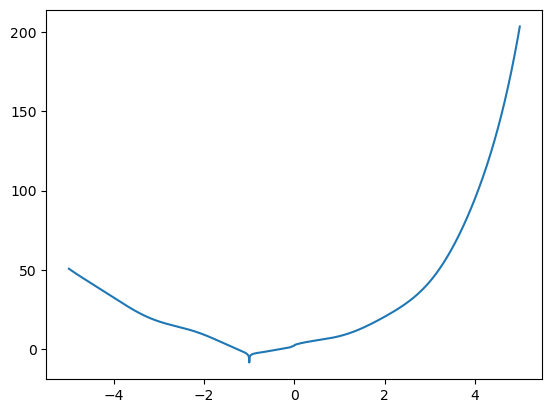

In [141]:
#print y vs x on graph, as well as predicted y vs x
import matplotlib.pyplot as plt
plt.plot(X, y)
plt.plot(X, net(torch.from_numpy(X).unsqueeze(1)).detach().numpy())
plt.show()